In [1]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [2]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [12]:
path_to_esc_results = Path("eval_jsin_results")

all_model_results = list(path_to_esc_results.rglob("*linear_eval_jsin_word*.pkl"))
all_model_results

[PosixPath('eval_jsin_results/mmcr_word_kell2018_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_linear_eval_jsin_word_task_AdamW_0.01_cosine_lr_scheduler__from_best_val_ckpt_with_noise.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_13_lr_06_LARS_linear_eval_jsin_word_clean_signals_LARS_0.1.pkl'),
 PosixPath('eval_jsin_results/barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_linear_eval_jsin_word_and_speaker_AdamW_0.001_from_best_val_ckpt_with_noise.pkl'),
 PosixPath('eval_jsin_results/barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_linear_eval_jsin_word_task_AdamW_0.01_cosine_lr_scheduler__from_best_val_ckpt_with_noise.pkl'),
 PosixPath('eval_jsin_results/barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_linear_eval_jsin_word_and_speaker_AdamW_0.001_with_noise.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpee

In [106]:

from decimal import Decimal
results_dfs = []
for result_file in all_model_results:
    result_dict = pd.read_pickle(result_file)
    result_dict['SSL'] = 'MMCR' if 'mmcr' in result_file.stem else 'BarlowTwins'
    result_dict['SSL_task'] = [task for task in ['word', 'audioset', 'dualtask'] if task in result_file.stem][0]
    result_dict['classifier_w_noise'] = '+ noise offline' if 'with_noise' in result_file.stem else ''
    result_dict['eval_task'] = 'speaker' if 'speaker' in result_file.stem else 'word'
    result_dict['train_set'] = "Matched w RandomCrop" if 'Matched' in str(result_file) else "Precombined" 
    result_dict['augment'] =  "+ Aug." if 'augment' in str(result_file) else "No Aug" 
    result_dict['w_schedule'] = "+ lr schedule" if 'cosine' in str(result_file) else "" 
    result_dict['arch'] = [arch for arch in ['kell2018', 'resnet18', 'resnet50'] if arch in result_file.stem][0]
    # result_dict['classifier_lr'] = Decimal(result_file.stem)


    # if 'best_val' in result_file.stem:
        # result_dict['proj_dim'] = f"{proj_size_dict[hpara_str]} best val ckpt"
    # else:
    # result_dict['proj_dim'] = str(proj_size_dict[hpara_str])
    # result_dict['plot_name'] = plot_name_dict[result_file.stem.split('_linear')[0]]

    results_dfs.append(result_dict)
df = pd.DataFrame.from_dict(results_dfs)
# df['mean_acc'] = df['mean_acc'].apply(lambda x: x.numpy())
# df['sem_acc'] = df['sem_acc'].apply(lambda x: x.numpy())
# df['std_acc'] = df['std_acc'].apply(lambda x: x.numpy())

df['plot_str'] = df['augment'] + "\n" + df['classifier_w_noise'] + "\n" + df['w_schedule']

In [107]:
df

,word_top1_mean,word_top1_sem,word_top5_mean,word_top5_sem,SSL,SSL_task,classifier_w_noise,eval_task,train_set,augment,w_schedule,arch,mean_acc,std_acc,sem_acc,speaker_top1_mean,speaker_top1_sem,speaker_top5_mean,speaker_top5_sem,plot_str
0,0.234568,0.000697,0.882037,0.000568,MMCR,word,+ noise offline,word,Matched w RandomCrop,+ Aug.,+ lr schedule,kell2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,+ Aug.\n+ noise offline\n+ lr schedule
1,NaN,NaN,NaN,NaN,BarlowTwins,word,,word,Precombined,No Aug,,resnet50,tensor(0.0160),tensor(0.1253),tensor(0.0002),NaN,NaN,NaN,NaN,No Aug\n\n
2,0.127652,0.000553,0.722476,0.000917,BarlowTwins,word,+ noise offline,speaker,Matched w RandomCrop,+ Aug.,,kell2018,NaN,NaN,NaN,0.697495,0.000742,0.970414,0.000280,+ Aug.\n+ noise offline\n
3,0.230203,0.000693,0.881569,0.000574,BarlowTwins,word,+ noise offline,word,Matched w RandomCrop,+ Aug.,+ lr schedule,kell2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,+ Aug.\n+ noise offline\n+ lr schedule
4,0.161602,0.000601,0.710823,0.000839,BarlowTwins,word,+ noise offline,speaker,Matched w RandomCrop,No Aug,,kell2018,NaN,NaN,NaN,0.784453,0.000664,0.983011,0.000212,No Aug\n+ noise offline\n
5,NaN,NaN,NaN,NaN,BarlowTwins,word,,word,Matched w RandomCrop,No Aug,,resnet50,tensor(0.0264),tensor(0.1604),tensor(0.0004),NaN,NaN,NaN,NaN,No Aug\n\n
6,0.228160,0.000695,0.886279,0.000575,MMCR,word,+ noise offline,word,Matched w RandomCrop,+ Aug.,+ lr schedule,kell2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,+ Aug.\n+ noise offline\n+ lr schedule
7,NaN,NaN,NaN,NaN,BarlowTwins,word,,word,Matched w RandomCrop,No Aug,,resnet50,tensor(0.0215),tensor(0.1449),tensor(0.0003),NaN,NaN,NaN,NaN,No Aug\n\n
8,0.163584,0.000599,0.861851,0.000636,BarlowTwins,word,,word,Matched w RandomCrop,No Aug,,kell2018,NaN,NaN,NaN,0.799882,0.000655,0.994950,0.000117,No Aug\n\n
9,0.226481,0.000697,0.885319,0.000583,BarlowTwins,word,+ noise offline,word,Matched w RandomCrop,+ Aug.,+ lr schedule,kell2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,+ Aug.\n+ noise offline\n+ lr schedule


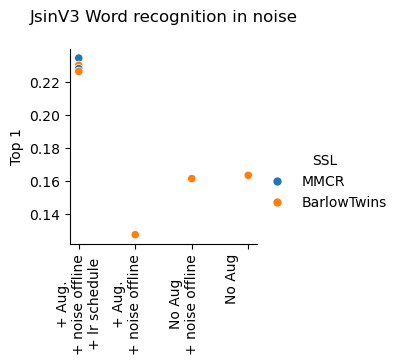

In [108]:

# fig, axs = plt.subplots(figsize=(2,4))
to_plot = df[~df["word_top1_mean"].isna()].copy()

g = sns.relplot(data=to_plot, x='plot_str', hue='SSL', y='word_top1_mean', height=3, aspect=1,  markers='.')
g.set_xticklabels(rotation=90)
axs = g.axes[0][0]
# axs.set_yticks(np.linspace(0,.2, 5))
axs.set_ylabel('Top 1')
axs.set_xlabel('')
axs.set_title('JsinV3 Word recognition in noise', y=1.1);
# plt.tight_layout()

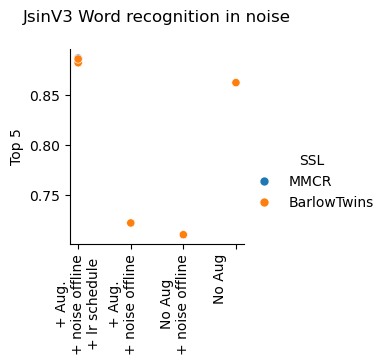

In [96]:

# fig, axs = plt.subplots(figsize=(2,4))
to_plot = df[~df["word_top1_mean"].isna()].copy()

g = sns.relplot(data=to_plot, x='plot_str', hue='SSL', y='word_top5_mean', height=3, aspect=1,  markers='.')
g.set_xticklabels(rotation=90)
axs = g.axes[0][0]
# axs.set_yticks(np.linspace(0,.2, 5))
axs.set_ylabel('Top 5')
axs.set_xlabel('')
axs.set_title('JsinV3 Word recognition in noise', y=1.1);
# plt.tight_layout()

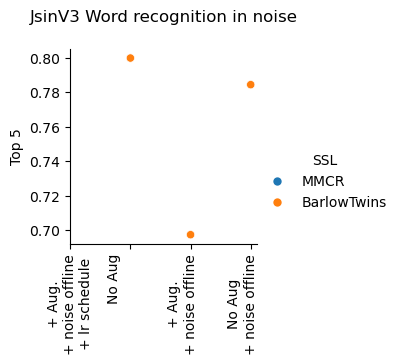

In [100]:

# fig, axs = plt.subplots(figsize=(2,4))
# to_plot = df[~df["word_top1_mean"].isna()].copy()

g = sns.relplot(data=df, x='plot_str', hue='SSL', y='speaker_top1_mean', height=3, aspect=1,  markers='.')
g.set_xticklabels(rotation=90)
axs = g.axes[0][0]
# axs.set_yticks(np.linspace(0,.2, 5))
axs.set_ylabel('Top 5')
axs.set_xlabel('')
axs.set_title('JsinV3 Word recognition in noise', y=1.1);
# plt.tight_layout()

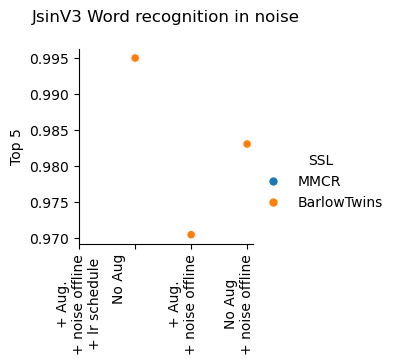

In [99]:

# fig, axs = plt.subplots(figsize=(2,4))
# to_plot = df[~df["word_top1_mean"].isna()].copy()

g = sns.relplot(data=df, x='plot_str', hue='SSL', y='speaker_top5_mean', height=3, aspect=1,  markers='.')
g.set_xticklabels(rotation=90)
axs = g.axes[0][0]
# axs.set_yticks(np.linspace(0,.2, 5))
axs.set_ylabel('Top 5')
axs.set_xlabel('')
axs.set_title('JsinV3 Word recognition in noise', y=1.1);
# plt.tight_layout()